In [58]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('../../../datasets/e_sports.csv')
df.head()

,record_id,player_id,team_name,player_role,map_played,match_type,kills,assists,deaths,accuracy_percent,reaction_time_ms,fatigue_index,performance_score,win_probability,match_outcome,mvp_award
0,1,160,Titan Esports,Flex,Dust Arena,Playoff,18,6,7,40.43,192.28,0.52,50.02,0.83,Win,No
1,2,2,Titan Esports,Support,Neon City,Final,16,7,11,40.50,201.98,0.68,41.45,0.89,Win,No
2,3,468,Team Alpha,Support,Neon City,Semi-Final,14,7,15,36.93,172.50,0.27,35.77,0.81,Win,No
3,4,447,Team Nova,IGL,Desert Storm,Final,12,6,13,53.46,246.83,0.07,43.03,1.00,Win,No
4,5,196,Phantom Squad,Sniper,Skyline,Playoff,13,9,13,44.71,266.94,0.52,39.16,0.85,Win,No


In [59]:
# Select the features and the target

features = ['kills', 'assists', 'accuracy_percent', 'fatigue_index', 'performance_score', 'mvp_award', 'reaction_time_ms', 'match_outcome']
df = df[features]
df.head()

,kills,assists,accuracy_percent,fatigue_index,performance_score,mvp_award,reaction_time_ms,match_outcome
0,18,6,40.43,0.52,50.02,No,192.28,Win
1,16,7,40.50,0.68,41.45,No,201.98,Win
2,14,7,36.93,0.27,35.77,No,172.50,Win
3,12,6,53.46,0.07,43.03,No,246.83,Win
4,13,9,44.71,0.52,39.16,No,266.94,Win


In [60]:
# Encoders
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['mvp_award'] = le.fit_transform(df['mvp_award'])
df['match_outcome'] = le.fit_transform(df['match_outcome'])

df.head()

,kills,assists,accuracy_percent,fatigue_index,performance_score,mvp_award,reaction_time_ms,match_outcome
0,18,6,40.43,0.52,50.02,0,192.28,1
1,16,7,40.50,0.68,41.45,0,201.98,1
2,14,7,36.93,0.27,35.77,0,172.50,1
3,12,6,53.46,0.07,43.03,0,246.83,1
4,13,9,44.71,0.52,39.16,0,266.94,1


In [61]:
# Split the data
from sklearn.model_selection import train_test_split

# Oversampling
from sklearn.utils import resample
df_miniority = df[df['match_outcome'] == 0]
df_miniority = resample(df_miniority, replace = True, n_samples=400, random_state=42)
df = pd.concat([df_miniority, df])


X = df.drop('match_outcome', axis = 1)
y = df['match_outcome']
                                                            
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, stratify=y, random_state = 42)

print(f'Len of train test: {X_train.shape}, {y_train.shape}')
print(f'Len of test size: {X_test.shape}, {y_test.shape}')

Len of train test: (2560, 7), (2560,)
Len of test size: (640, 7), (640,)


In [62]:
# Get the models, scaler, metrics and pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, recall_score, f1_score, precision_score, ConfusionMatrixDisplay

models = [LogisticRegression(class_weight='balanced', random_state=42), DecisionTreeClassifier(max_depth=7, splitter='best'), RandomForestClassifier(max_depth = 7,  n_estimators = 100)]

----------------------------------------
Model: LogisticRegression
Train Metrics: Accuracy:0.931 | F1: 0.873 | Precision: 0.824 | Recall: 0.960|
Test Metrics: Accuracy:0.938 | F1: 0.882 | Precision: 0.835 | Recall: 0.964 | 
Confusion Matriz:


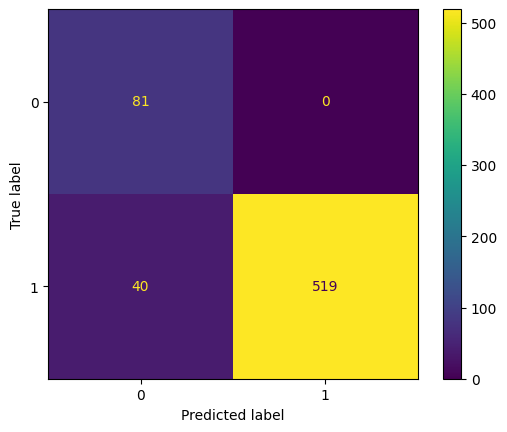

----------------------------------------
Model: DecisionTreeClassifier
Train Metrics: Accuracy:0.995 | F1: 0.988 | Precision: 0.979 | Recall: 0.997|
Test Metrics: Accuracy:0.994 | F1: 0.986 | Precision: 0.976 | Recall: 0.996 | 
Confusion Matriz:


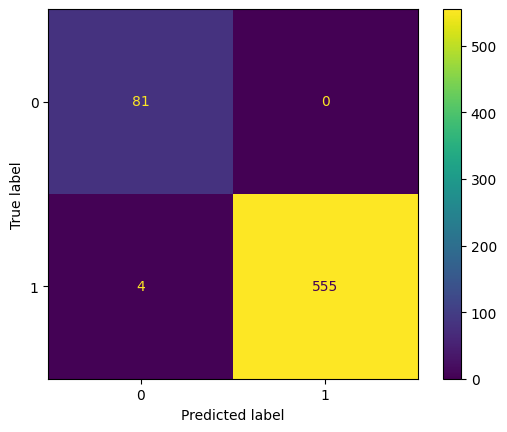

----------------------------------------
Model: RandomForestClassifier
Train Metrics: Accuracy:1.000 | F1: 0.999 | Precision: 0.998 | Recall: 1.000|
Test Metrics: Accuracy:1.000 | F1: 1.000 | Precision: 1.000 | Recall: 1.000 | 
Confusion Matriz:


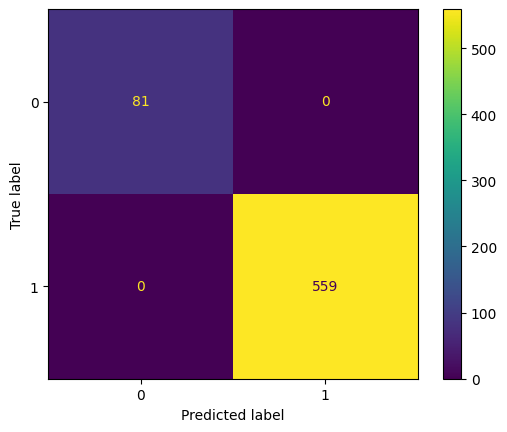

In [63]:
# The pipeline

for model in models:
    print('----------------------------------------')
    print(f"Model: {model.__class__.__name__}")

    pipe = Pipeline(
        steps=[
            ("Scaler", StandardScaler()),
            ("Model", model)
        ]
    )

    # TRAIN THE MODEL
    pipe.fit(X_train, y_train)

    # See if overfitting (predict the train pipe)
    y_preds_train = pipe.predict(X_train)
    accuracy = accuracy_score(y_train, y_preds_train)
    f1 = f1_score(y_train, y_preds_train, average = 'macro')
    precision = precision_score(y_train, y_preds_train, average = 'macro')
    recall = recall_score(y_train, y_preds_train, average = 'macro')
    print(f"Train Metrics: Accuracy:{accuracy:.3f} | F1: {f1:.3f} | Precision: {precision:.3f} | Recall: {recall:.3f}|")

    # See the metrics (test set)
    y_preds_test = pipe.predict(X_test)
    accuracy = accuracy_score(y_test, y_preds_test)
    f1 = f1_score(y_test, y_preds_test, average = 'macro')
    precision = precision_score(y_test, y_preds_test, average = 'macro')
    recall = recall_score(y_test, y_preds_test, average = 'macro')
    confusion_m = ConfusionMatrixDisplay.from_predictions(y_test, y_preds_test)
    print(f"Test Metrics: Accuracy:{accuracy:.3f} | F1: {f1:.3f} | Precision: {precision:.3f} | Recall: {recall:.3f} | \nConfusion Matriz:")
    plt.show()
